In [9]:
#Initial Imports
from astropy.io import fits
from scipy.ndimage import median_filter
import numpy as np
from photutils.detection import DAOStarFinder
from scipy.optimize import curve_fit, linear_sum_assignment
import matplotlib.pyplot as plt
import math
import pandas as pd
import re
import matplotlib.colors as mcolors
import colorsys
import os

In [10]:
#Lists for fits file paths to be processed, as well as detector temps
#Entries in the temps list must correspond to and be in the same order as the images
output_csv = r"Dark_Current_Summary_Stats.csv"
filenames = [r"Y:\2D\20260406\iLocater_lab_20260406_0001_hxrgproc.fits",
r"Y:\2D\20260406\iLocater_lab_20260406_0002_hxrgproc.fits",
r"Y:\2D\20260407\iLocater_lab_20260407_0001_hxrgproc.fits",
r"Y:\2D\20260407\iLocater_lab_20260407_0002_hxrgproc.fits",
r"Y:\2D\20260409\iLocater_lab_20260409_0001_hxrgproc.fits",
r"Y:\2D\20260409\iLocater_lab_20260409_0002_hxrgproc.fits",
r"Y:\2D\20260410\iLocater_lab_20260410_0001_hxrgproc.fits",
r"Y:\2D\20260410\iLocater_lab_20260410_0002_hxrgproc.fits",
r"Y:\2D\20260411\iLocater_lab_20260411_0001_hxrgproc.fits",
r"Y:\2D\20260411\iLocater_lab_20260411_0002_hxrgproc.fits",
r"Y:\2D\20260412\iLocater_lab_20260412_0001_hxrgproc.fits",
r"Y:\2D\20260412\iLocater_lab_20260412_0002_hxrgproc.fits",
r"Y:\2D\20260413\iLocater_lab_20260413_0001_hxrgproc.fits",
r"Y:\2D\20260413\iLocater_lab_20260413_0002_hxrgproc.fits",
r"Y:\2D\20260414\iLocater_lab_20260414_0001_hxrgproc.fits",
r"Y:\2D\20260414\iLocater_lab_20260414_0002_hxrgproc.fits",
r"Y:\2D\20260415\iLocater_lab_20260415_0001_hxrgproc.fits",
r"Y:\2D\20260415\iLocater_lab_20260415_0002_hxrgproc.fits"]
temps = [130.738, 130.755, 121.429, 121.461, 102.087, 102.078, 95.8237, 95.8189, 90.8267, 90.8215, 88.1519, 88.1490, 86.4587, 86.4556, 84.8636, 84.8621, 83.7054, 83.7017]


In [ ]:
"""
Fits file processing function. 
Takes lists of filepaths and their respective detector temperatures.
Calculates mean current across the entire image, as well as standard deivation and variance.
Generates a scatterplot of detector temp vs mean current, and saves all stats in a CSV called "Dark_Current_Summary_Stats.csv"
CSV saving is optional and can be turned off by changing the "exportcsv" kwarg to 0.
"""
def process_fits(filenames = filenames, temps = temps, exportcsv=1):
    rows = []
    for filename in filenames:
        print(filename)
        data = fits.getdata(filename)

        n = data.size
        total = np.sum(data)
        mean = np.nanmean(data)
        std = np.nanstd(data)
        sem = std / np.sqrt(n)
        var = std**2

        #build a list of stats for the files in the input list
        rows.append({
            "Filename": os.path.basename(filename),
            "Total Readout": total,
            "Total Readout Uncertainty": n * sem,
            "Mean Readout (Per Pixel)": mean,
            "Standard Deviation (Per Pixel)": std,
            "Standard Error in the Pixel Mean": sem,
            "Variance (Per Pixel)": var
        })
    
    #plot data vs temperature
    df = pd.DataFrame(rows)
    temp_array = np.asarray(temps)
    y2 = df["Mean Readout (Per Pixel)"].to_numpy()
    y1 = df["Total Readout"].to_numpy()
    y2err = df["Standard Error in the Pixel Mean"].to_numpy()
    y1err = df["Total Readout Uncertainty"].to_numpy()

    even = np.arange(len(temp_array)) % 2 == 0
    odd = ~even

    #plot the total dark current per image
    fig, axes = plt.subplots(2, 1, sharex = True, figsize = (7,8))
    fig.suptitle("Dark Current Stats by Detector Temperature")

    #Plot stats for whole images
    axes[0].errorbar(temp_array[even], y1[even], 
    yerr = y1err[even],
    fmt="o", c="blue", capsize=3, markersize=4, alpha=0.75, label="Short Exposure")
    axes[0].errorbar(temp_array[odd], y1[odd], 
    yerr = y1err[odd],
    fmt="o", c="orange", capsize=3, markersize=4, alpha=0.75, label="Long Exposure")
    axes[0].set_ylabel("Total Dark Current (ADU/Frame)")
    axes[0].grid(True, alpha=0.6, which="both")
    axes[0].legend()

    #plot per pixes stats as well
    axes[1].errorbar(
        temp_array[even], y2[even],
        yerr = y2err[even],
        fmt="o", c="red", capsize=3, markersize=4, alpha=0.75, label="Short Exposure"
    )
    
    axes[1].errorbar(
        temp_array[odd], y2[odd],
        yerr=y2err[odd], 
        fmt="o", c="green", capsize=3, markersize=4, alpha=0.75, label="Long Exposure"
    )
    axes[1].set_xlabel("Detector Temperature (K)")
    axes[1].set_ylabel("Mean Dark Current Per Pixel (ADU/Frame/Pixel)")
    axes[1].grid(True, alpha=0.6, which="both")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    #turn the data list into an exported csv
    if exportcsv == True:
        df.to_csv(output_csv, index=False)

Y:\2D\20260406\iLocater_lab_20260406_0001_hxrgproc.fits
Y:\2D\20260406\iLocater_lab_20260406_0002_hxrgproc.fits
Y:\2D\20260407\iLocater_lab_20260407_0001_hxrgproc.fits
Y:\2D\20260407\iLocater_lab_20260407_0002_hxrgproc.fits
Y:\2D\20260409\iLocater_lab_20260409_0001_hxrgproc.fits
Y:\2D\20260409\iLocater_lab_20260409_0002_hxrgproc.fits
Y:\2D\20260410\iLocater_lab_20260410_0001_hxrgproc.fits
Y:\2D\20260410\iLocater_lab_20260410_0002_hxrgproc.fits
Y:\2D\20260411\iLocater_lab_20260411_0001_hxrgproc.fits
Y:\2D\20260411\iLocater_lab_20260411_0002_hxrgproc.fits
Y:\2D\20260412\iLocater_lab_20260412_0001_hxrgproc.fits
Y:\2D\20260412\iLocater_lab_20260412_0002_hxrgproc.fits
Y:\2D\20260413\iLocater_lab_20260413_0001_hxrgproc.fits
Y:\2D\20260413\iLocater_lab_20260413_0002_hxrgproc.fits
Y:\2D\20260414\iLocater_lab_20260414_0001_hxrgproc.fits
Y:\2D\20260414\iLocater_lab_20260414_0002_hxrgproc.fits
Y:\2D\20260415\iLocater_lab_20260415_0001_hxrgproc.fits
Y:\2D\20260415\iLocater_lab_20260415_0002_hxrgpr

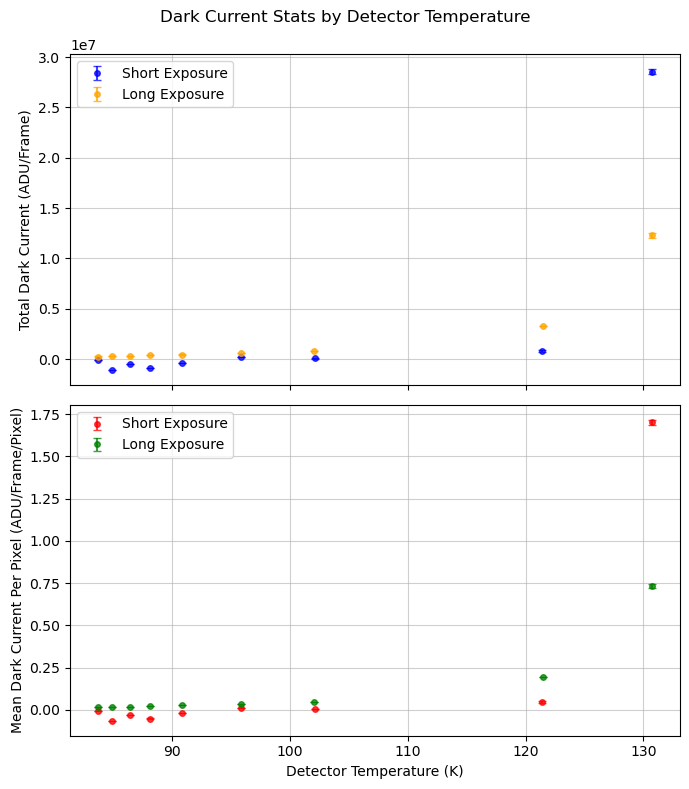

In [12]:
#Run fits processing function
process_fits()